<a href="https://colab.research.google.com/github/xqwu1108-create/MSE1003H_XueqiuWu_1011808741/blob/main/Assignment3_XWu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.Introduction**

This report describes a single-objective optimization task: finding the RYB dye combination that best matches a given target 8-channel spectral response from the Opentron-2 color-mixing platform. I started with 414 measurements collected from students_data, covering a broad range of RYB compositions across the simplex. A Gaussian Process Regressor (GPR) was trained on the initial data, with MinMaxScaler applied to both inputs and outputs. The model achieved an R² of only 0.17 on training sets and 0.15 on test sets, indicating poor predictive accuracy. Despite the low R², a simple active learning approach was used. I generate a large number of candidate RYB points on the simplex, predict their sensor responses with the GPR, and select the candidates with the smallest predicted Euclidean distance to the target. 13 new data were submitted. For evaluation, we inspected True vs Predicted plots on training and test sets and tracked RMSE, R², and predictive uncertainty over active learning rounds. The primary stopping criterion was the distance to the target vector.

# **2. Analysis**

# **2.1 Load the data**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, ConstantKernel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import ast
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 403

In [ ]:
import glob
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/students_data'
all_files = glob.glob(os.path.join(data_path, "*.csv"))
def process_custom_csv(file_path):
    # Read the raw CSV
    df = pd.read_csv(file_path)
    # Extract filename for 'source_file' column
    file_name = os.path.basename(file_path).replace('.csv', '')
    df['source_file'] = file_name
    # Convert string-dictionaries to actual dictionaries
    df['Command'] = df['Command'].apply(ast.literal_eval)
    df['Sensor Data'] = df['Sensor Data'].apply(ast.literal_eval)
    # Expand Command and Sensor Data into separate columns
    command_cols = pd.json_normalize(df['Command'])
    sensor_cols = pd.json_normalize(df['Sensor Data'])
    # Combine everything together
    processed_df = pd.concat([
        df[['Experiment ID', 'timestamp', 'source_file']],
        command_cols,
        sensor_cols
    ], axis=1)

    return processed_df
# Load and combine all data
if not all_files:
    print("No CSV files found!")
else:
    li = []
    for filename in all_files:
        temp_df = process_custom_csv(filename)
        li.append(temp_df)
    # Final combined DataFrame
    raw_data = pd.concat(li, axis=0, ignore_index=True)

    print("Data loaded successfully!")
    print(raw_data.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded successfully!
  Experiment ID                timestamp        source_file           R  \
0      f69dbab0  2025-02-21 02:28:45.967  013_filtered_data   11.524150   
1      b91dd8ae  2025-02-21 02:30:47.786  013_filtered_data   40.726160   
2      8ae8b0a7  2025-02-21 02:32:49.374  013_filtered_data  150.227895   
3      5eefff30  2025-02-21 02:34:50.012  013_filtered_data  208.821602   
4      c7aa82f4  2025-02-21 02:36:50.528  013_filtered_data  130.196335   

            Y           B well  ch583  ch670  ch510  ch410  ch620  ch470  \
0  150.567865  127.836631   D4   4087   5053   2574    348   6127   1539   
1  162.439788   78.092528   D5   4423   5386   2654    368   6601   1597   
2   75.057023   59.351964   D6   4494   5488   2438    372   6751   1557   
3   20.800371   23.413566   D7   4673   5656   2400    381   7032   1578   
4  110.099784 

In [ ]:
# Define input features (RYB volumes) and target responses (8-channel sensor data)
X = raw_data[['R', 'Y', 'B']]
y = raw_data[['ch583', 'ch670', 'ch510', 'ch410', 'ch620', 'ch470', 'ch550', 'ch440']]

In [ ]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

In [ ]:
# Normalize the data using MinMaxScaler to scale features between 0 and 1
scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

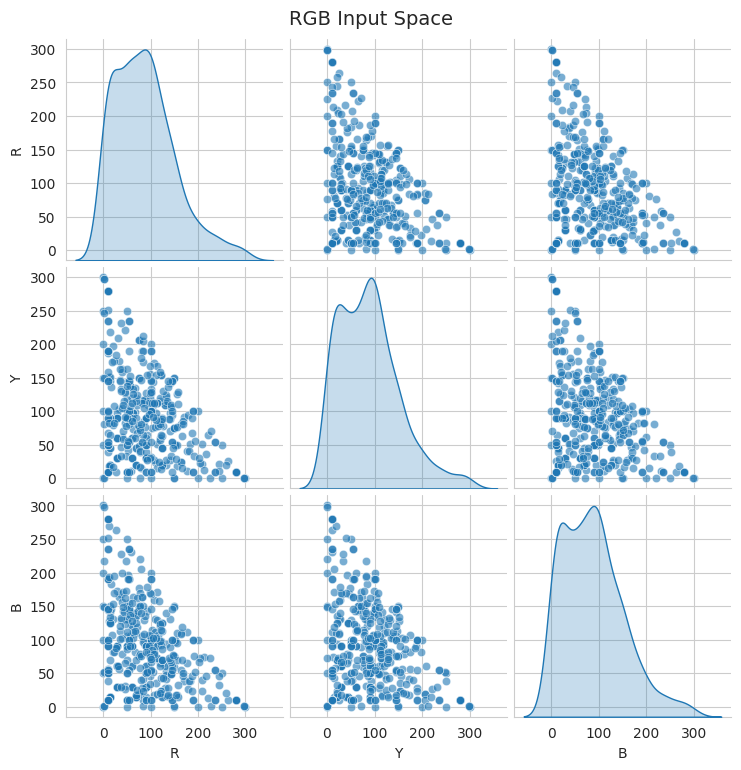

In [ ]:
sns.set_style("whitegrid")
# Pairplot of RGB inputs: Visualizing the distribution and coverage of sampling points
fig1 = sns.pairplot(X, diag_kind='kde', plot_kws={'alpha': 0.6})
fig1.fig.suptitle('RGB Input Space', y=1.02, fontsize=14)
plt.show()

All three components are right-skewed, with the majority of samples concentrated at lower volumes and relatively few samples at high volumes near 300 µL. The scatter plots show a clear negative correlation between each pair of components. This suggests the RGB design points are constrained by mixture-like relationships and the input space is not uniformly covered

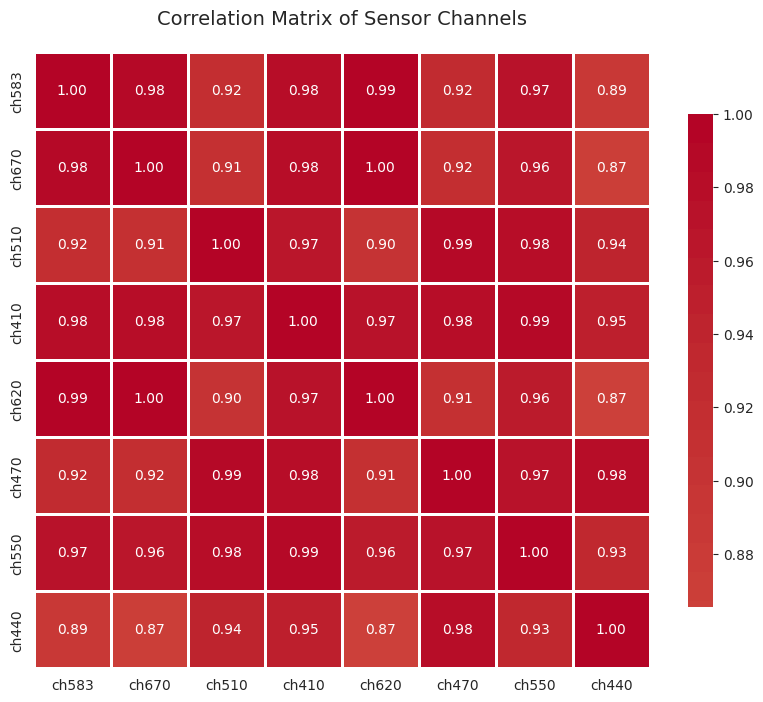

In [ ]:
# Correlation heatmap of sensor outputs: Checking for redundancy between 8 channels
plt.figure(figsize=(10, 8))
corr_matrix = y.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Sensor Channels', fontsize=14, pad=20)
plt.show()

All 8 sensor channels are very strongly positively correlated with each other, with correlation coefficients ranging from 0.87 to 1.00. This high inter-channel redundancy indicates that the 8 channels largely capture a single dominant signal.

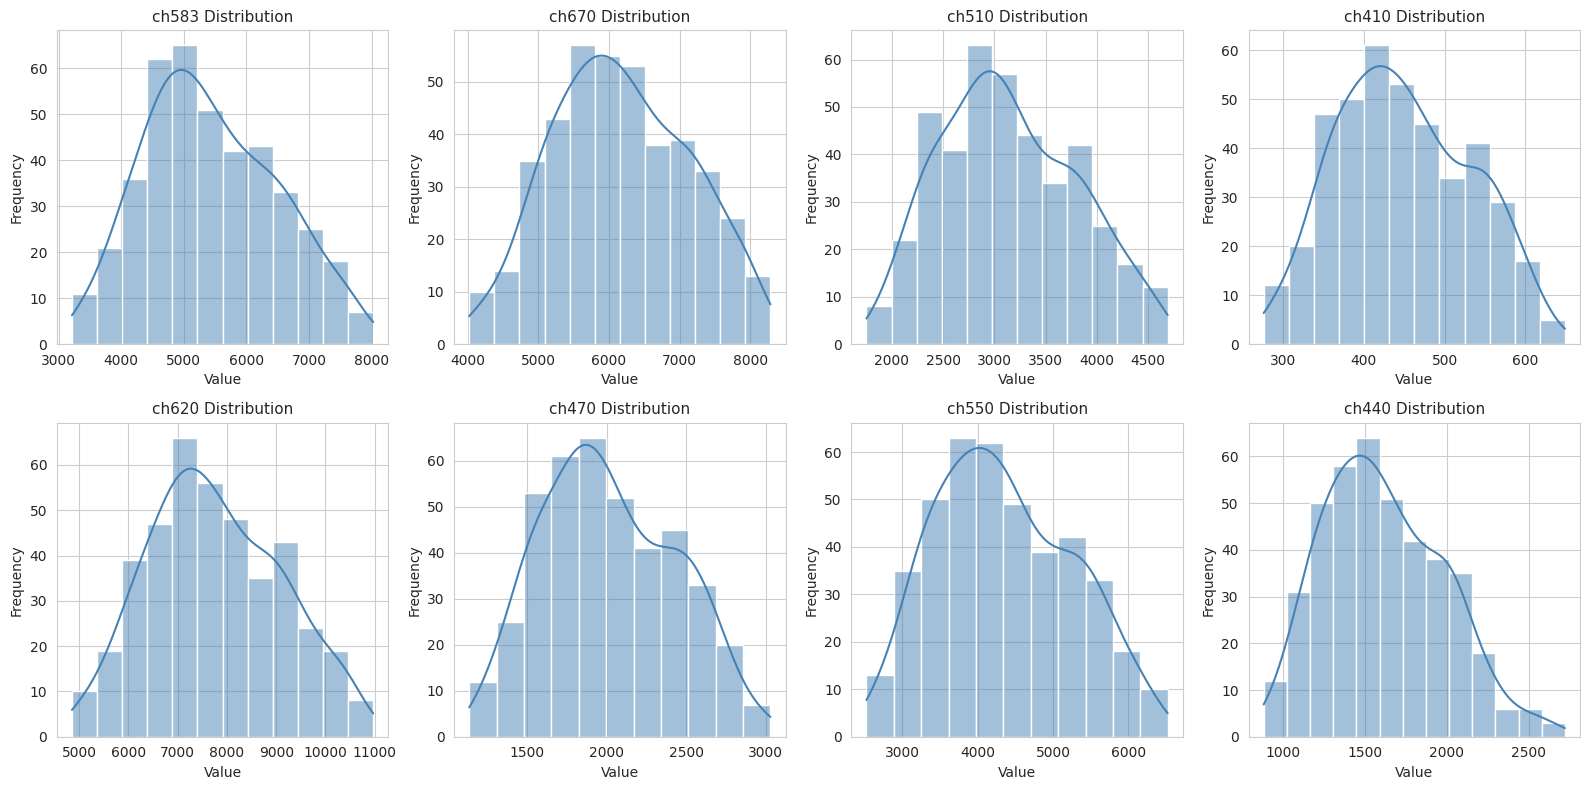

In [ ]:
# Distribution plots for sensor channels: Checking data spread and outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
sensor_cols = ['ch583', 'ch670', 'ch510', 'ch410', 'ch620', 'ch470', 'ch550', 'ch440']

for idx, col in enumerate(sensor_cols):
    sns.histplot(y[col], kde=True, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{col} Distribution', fontsize=11)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Each channel exhibits an approximately bell-shaped distribution with moderate spread. The channels span very different absolute ranges. ch410 is the lowest , while ch620 is the highest. These differences should be considered when designing the objective function, as channels with larger absolute values will naturally dominate the Euclidean distance metric.

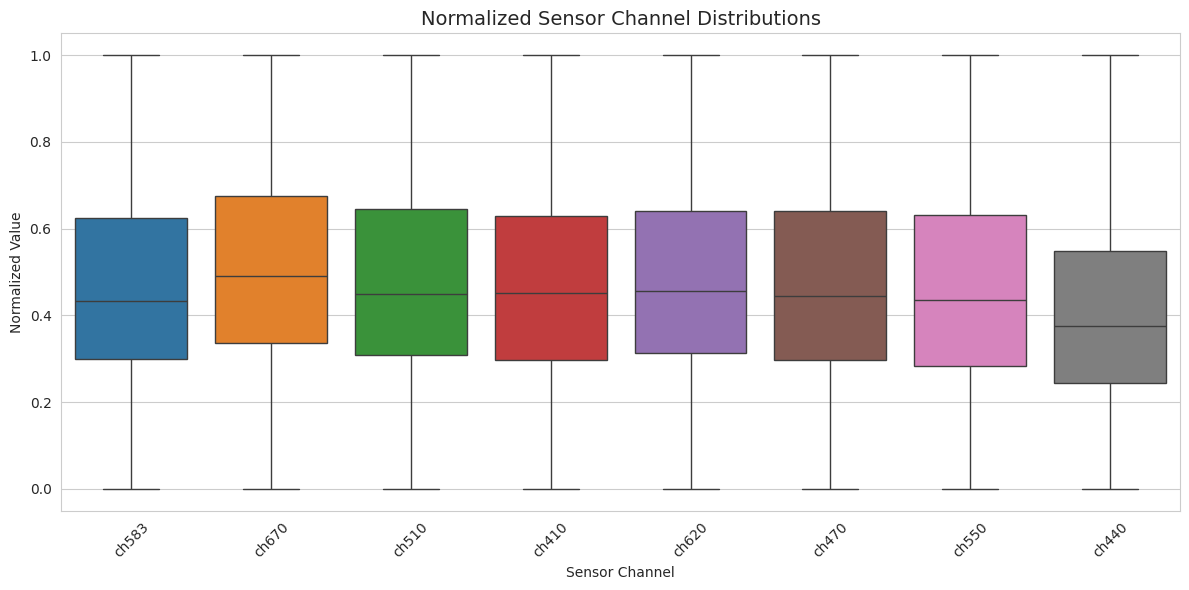

In [ ]:
# Boxplot comparing sensor channels: Identifying variations in sensor sensitivity
plt.figure(figsize=(12, 6))
y_normalized = (y - y.min()) / (y.max() - y.min())
sns.boxplot(data=y_normalized)
plt.title('Normalized Sensor Channel Distributions', fontsize=14)
plt.xlabel('Sensor Channel')
plt.ylabel('Normalized Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

After min-max normalization, all 8 channels show similar ranges spanning roughly 0.25 to 0.65, confirming that the raw value differences between channels are primarily a matter of scale rather than fundamentally different distributions. The median values are clustered around 0.4–0.5 for most channels.

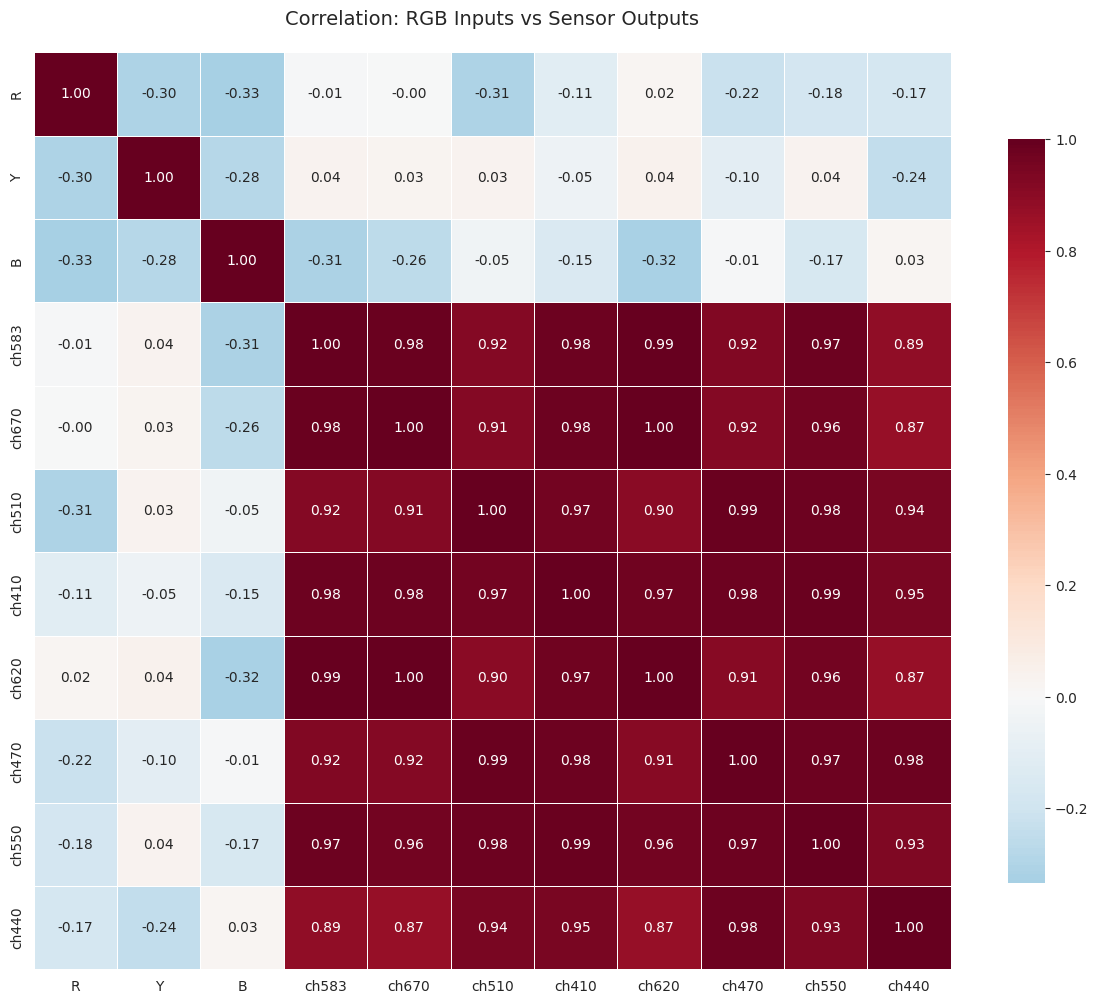

In [ ]:
#  Heatmap: Relationship between RGB inputs and sensor outputs
combined = pd.concat([X, y], axis=1)
plt.figure(figsize=(12, 10))
corr_all = combined.corr()
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation: RGB Inputs vs Sensor Outputs', fontsize=14, pad=20)
plt.tight_layout()
plt.show()



None of the individual RGB inputs are strongly correlated with any sensor channel (all |r| < 0.33). This weak linear relationship between individual inputs and outputs suggests the response function is highly nonlinear.

# **2.2 Trian GPR model**

In [ ]:
kernel = RBF() + WhiteKernel() + ConstantKernel()
gpr_model = GPR(kernel=kernel, random_state=RANDOM_SEED)
gpr_model.fit(X_train_scaled, y_train_scaled)

GaussianProcessRegressor(kernel=RBF(length_scale=1) + WhiteKernel(noise_level=1) + 1**2,
                         random_state=403)

In [ ]:
# Evaluate performance on the Training set
train_score = gpr_model.score(X_train_scaled, y_train_scaled)
print(f"Training R^2 Score: {train_score}")
# Get predictions and uncertainty for training data
y_train_predict, y_train_std = gpr_model.predict(X_train_scaled, return_std=True)

Training R^2 Score: 0.1666827136530859


In [ ]:
# Evaluate performance on the Test set
test_score = gpr_model.score(X_test_scaled, y_test_scaled)
print(f"Test R^2 Score: {test_score}")
# Get predictions and uncertainty for test data
y_test_predict, y_test_std = gpr_model.predict(X_test_scaled, return_std=True)

Test R^2 Score: 0.1504689597101663


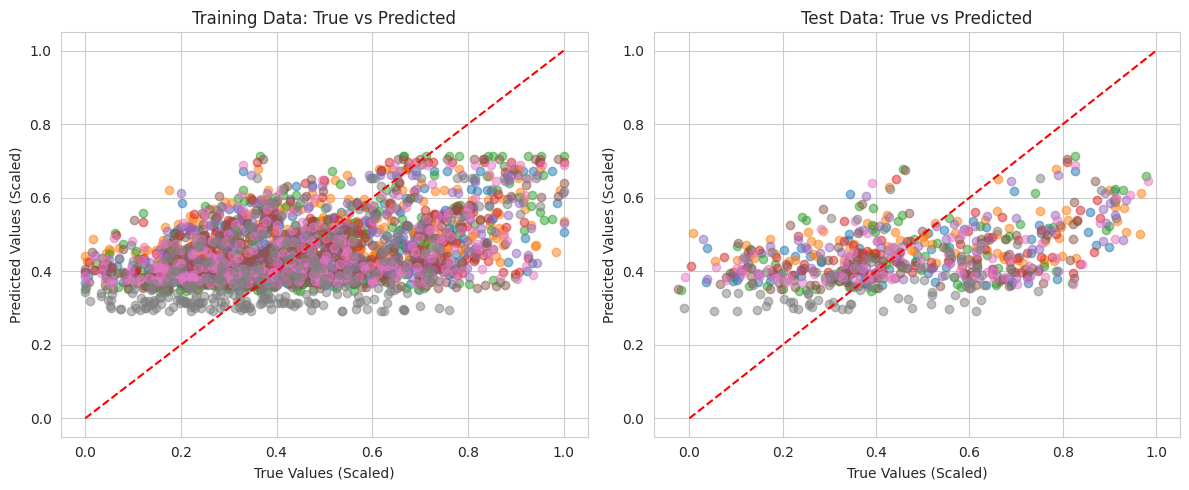

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Plot Training Data: True vs Predicted for all 8 channels
for i in range(8):
    ax[0].scatter(y_train_scaled[:, i], y_train_predict[:, i], alpha=0.5, label=f'Channel {i+1}')
ax[0].set_title("Training Data: True vs Predicted")
ax[0].set_xlabel("True Values (Scaled)")
ax[0].set_ylabel("Predicted Values (Scaled)")
ax[0].plot([0, 1], [0, 1], 'r--')

# Plot Test Data: True vs Predicted for all 8 channels
for i in range(8):
    ax[1].scatter(y_test_scaled[:, i], y_test_predict[:, i], alpha=0.5, label=f'Channel {i+1}')
ax[1].set_title("Test Data: True vs Predicted")
ax[1].set_xlabel("True Values (Scaled)")
ax[1].set_ylabel("Predicted Values (Scaled)")
ax[1].plot([0, 1], [0, 1], 'r--')

plt.tight_layout()
plt.show()

The plots show poor agreement between true and predicted values for both the training set (R² = 0.167) and test set (R² = 0.150).

Created mesh with 1326 points


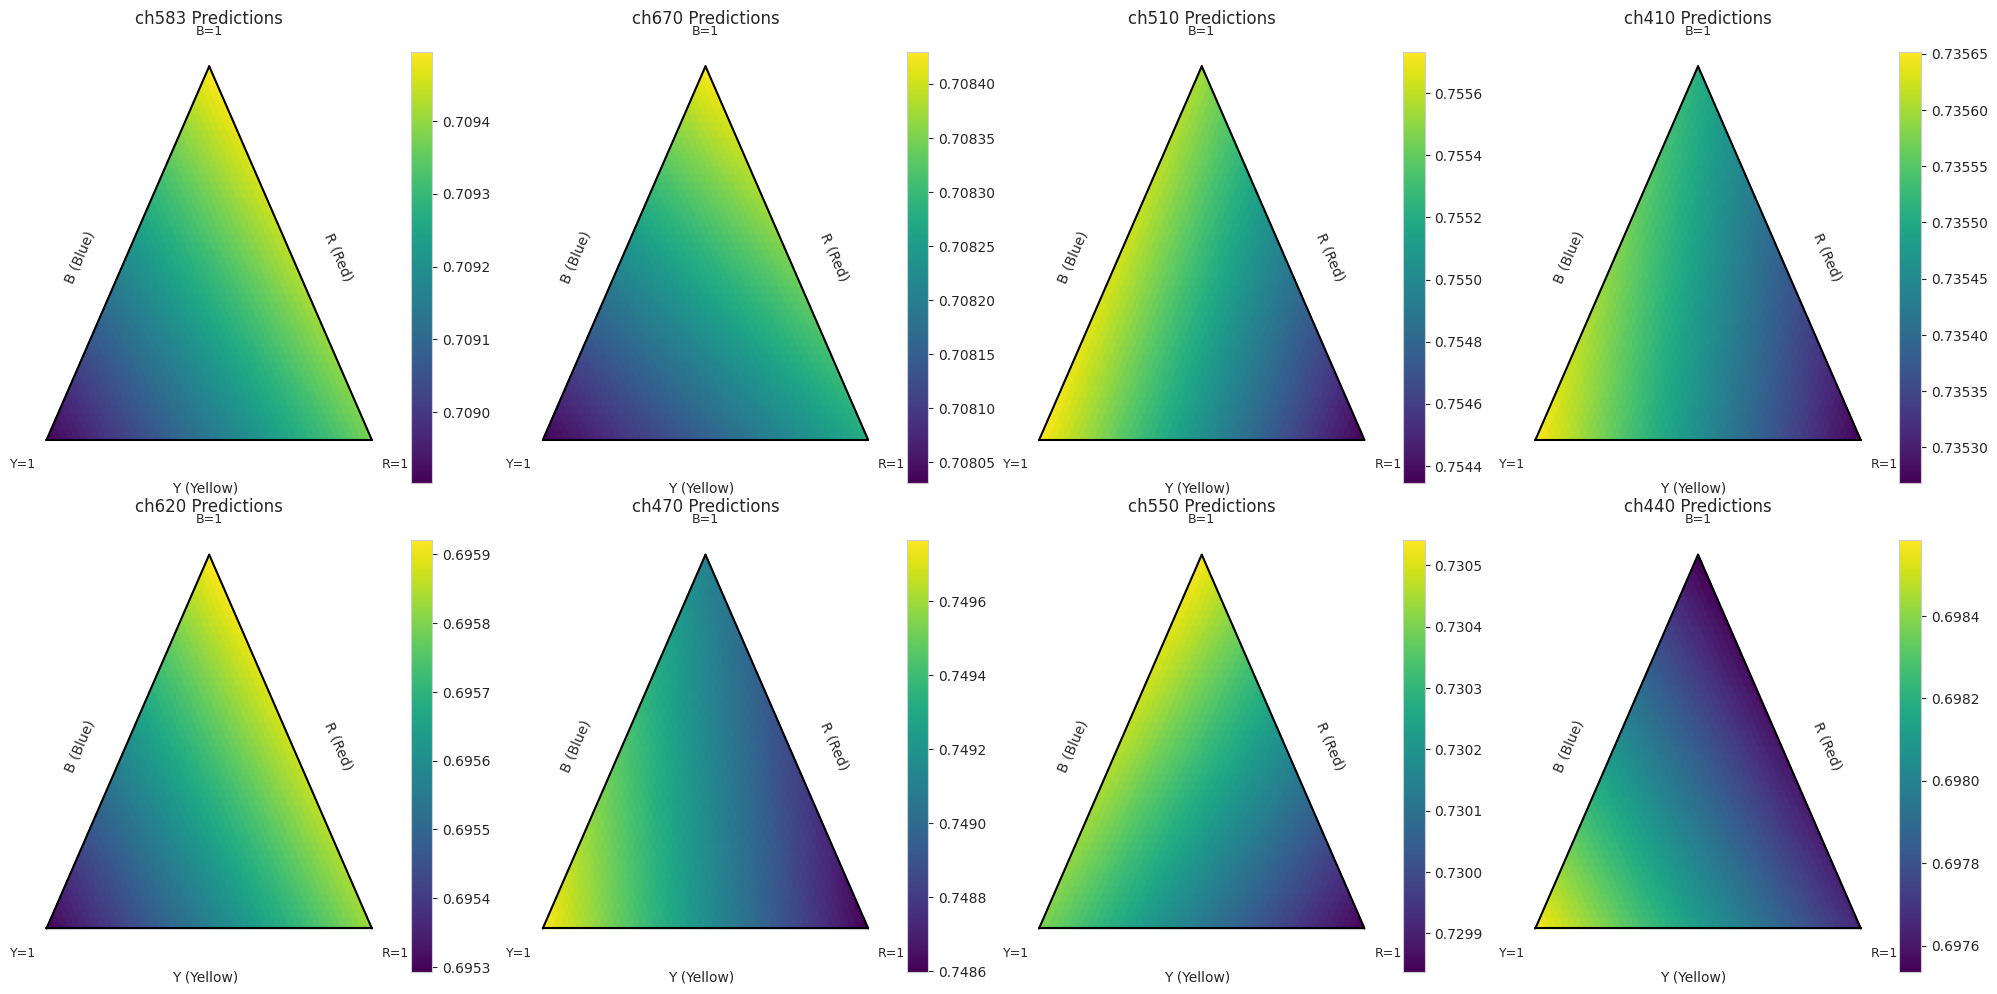

In [ ]:
!pip install python-ternary
import ternary

# Create a mesh of points in RYB space
def create_ternary_mesh(scale=100):
    points = []
    for i in range(scale + 1):
        for j in range(scale + 1 - i):
            k = scale - i - j
            # Normalize to [0, 1] for the GPR model input
            R, Y, B = i / scale, j / scale, k / scale
            points.append([R, Y, B])
    return np.array(points)

# Create mesh with a specific resolution
scale = 50
mesh_points = create_ternary_mesh(scale)
print(f"Created mesh with {len(mesh_points)} points")

# Scale the mesh points using the SAME scaler from training
mesh_scaled = scaler.transform(mesh_points)

# Predict using GPR Model
mesh_predictions, mesh_std = gpr_model.predict(mesh_scaled, return_std=True)

# Plot Ternary Heatmaps for each channel
sensor_names = ['ch583', 'ch670', 'ch510', 'ch410', 'ch620', 'ch470', 'ch550', 'ch440']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, sensor_name in enumerate(sensor_names):
    predictions = mesh_predictions[:, idx]
    data_dict = {}
    for i, point in enumerate(mesh_points):
        R_int = int(round(point[0] * scale))
        Y_int = int(round(point[1] * scale))
        B_int = int(round(point[2] * scale))
        data_dict[(R_int, Y_int, B_int)] = predictions[i]

    ax = axes[idx]
    ax.axis('off')
    figure, tax = ternary.figure(scale=scale, ax=ax)

    tax.heatmap(data_dict, style='hexagonal', colorbar=True, cmap='viridis')
    tax.boundary()
    tax.set_title(f'{sensor_name} Predictions', fontsize=12, pad=20)

    tax.left_axis_label("B (Blue)", fontsize=10, offset=0.15)
    tax.right_axis_label("R (Red)", fontsize=10, offset=0.15)
    tax.bottom_axis_label("Y (Yellow)", fontsize=10, offset=0.05)

    tax.top_corner_label("B=1", fontsize=9)
    tax.left_corner_label("Y=1", fontsize=9)
    tax.right_corner_label("R=1", fontsize=9)
    tax.clear_matplotlib_ticks()

plt.tight_layout()
plt.savefig('ternary_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

The ternary heatmaps display the GPR's predicted sensor responses across the entire RYB composition space. The predicted variation across the simplex is extremely small for every channel. This suggests the model fails to learn the true spatial structure.

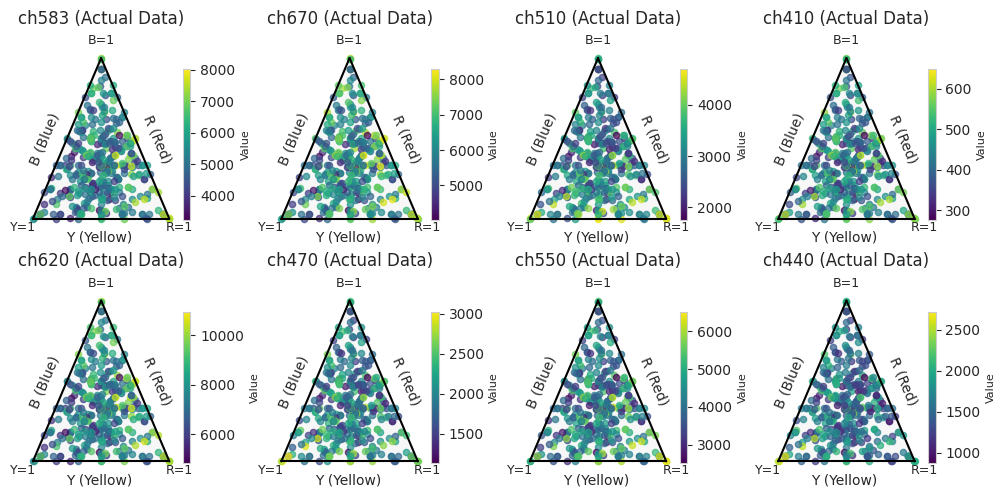


Ternary diagrams saved as 'ternary_actual_data.png'


In [ ]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize
# Prepare Data
X_all = pd.concat([X_train, X_test], axis=0).values
y_all = pd.concat([y_train, y_test], axis=0).values

# Normalize X to ensure R + Y + B = 1.0 (scale) for ternary coordinates
X_sum = X_all.sum(axis=1, keepdims=True)
X_normalized = X_all / X_sum

# Define the sensor names as per the dataset
sensor_names = ['ch583', 'ch670', 'ch510', 'ch410', 'ch620', 'ch470', 'ch550', 'ch440']

# Create Subplots for Actual Data
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for idx, sensor_name in enumerate(sensor_names):
    sensor_values = y_all[:, idx]

    # Normalize colors based on the min/max of current sensor's values
    norm = Normalize(vmin=sensor_values.min(), vmax=sensor_values.max())
    cmap = cm.get_cmap('viridis')

    ax = axes[idx]
    ax.axis('off')
    figure, tax = ternary.figure(scale=1.0, ax=ax)

    # Plot each experimental data point as a scatter dot
    for i in range(len(X_normalized)):
        R, Y, B = X_normalized[i]
        color = cmap(norm(sensor_values[i]))
        tax.scatter([(Y, R, B)], marker='o', color=color, s=20, alpha=0.7)

    tax.boundary()
    tax.set_title(f'{sensor_name} (Actual Data)', fontsize=12, pad=20)
    tax.left_axis_label("B (Blue)", fontsize=10, offset=0.15)
    tax.right_axis_label("R (Red)", fontsize=10, offset=0.15)
    tax.bottom_axis_label("Y (Yellow)", fontsize=10, offset=0.05)
    tax.top_corner_label("B=1", fontsize=9)
    tax.left_corner_label("Y=1", fontsize=9)
    tax.right_corner_label("R=1", fontsize=9)
    tax.clear_matplotlib_ticks()

    # Add colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Value', fontsize=8)

# Final layout adjustments and saving
plt.tight_layout()
plt.savefig('ternary_actual_data.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTernary diagrams saved as 'ternary_actual_data.png'")

In contrast to the flat GPR predictions, the actual sensor data shows rich spatial variation across the simplex. The data points are densest in the central region of the simplex and sparser near the vertices. The actual ternary patterns highlight significant nonlinear structure that the GPR model struggles to capture, reinforcing the need for active learning to guide sampling toward the target.

# **2.3 Simple Active learning**

Objective function: $f(\mathbf{x}) = \sqrt{\sum_{i=1}^{8}\left(y_i(\mathbf{x}) - y_i^{\mathrm{target}}\right)^2}$  
Acquisition: Greedy exploitation (min predicted distance) + adaptive local exploration  
Constraint: R + Y + B = 300, each >=10  

The initial GPR has low R², meaning uncertainty estimates are unreliable. Standard BO acquisition functions depend on calibrated uncertainty. When the model is poor, they can waste budget on uninformative points. Therefore, I chose simple active learning instead of Bayesian Optimization. I over-sample candidates densely, pick the one with min predicted distance.

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor as GPR_Model
from sklearn.metrics import r2_score, mean_squared_error
np.random.seed(RANDOM_SEED)

# target
SENSOR_COLS = ["ch410", "ch440", "ch470", "ch510", "ch550", "ch583", "ch620", "ch670"]
target_raw  = np.array([554, 2061, 2635, 4227, 5758, 6794, 9325, 7313], dtype=float)
TOTAL_VOL   = 300.0

# Load initial data
X_init = raw_data[['R', 'Y', 'B']].values.copy()
Y_init = raw_data[SENSOR_COLS].values.copy()
print(f"Initial data  : {X_init.shape[0]} samples")
print(f"Target  : {target_raw}")
print(f"Channels      : {SENSOR_COLS}")

Initial data  : 414 samples
Target  : [ 554. 2061. 2635. 4227. 5758. 6794. 9325. 7313.]
Channels      : ['ch410', 'ch440', 'ch470', 'ch510', 'ch550', 'ch583', 'ch620', 'ch670']


In [ ]:
def simplex_global(n, vol=TOTAL_VOL, min_val=10):
    """Uniform random on the R+Y+B=vol simplex, each component >= min_val."""
    remainder = vol - 3 * min_val  # allocatable portion after reserving minimums
    props = np.random.dirichlet([1,1,1], size=n) * remainder
    return props + min_val

def simplex_local(center, n, scale, vol=TOTAL_VOL, min_val=10):
    pts = center + np.random.randn(n, 3) * scale
    pts = np.clip(pts, min_val, None)
    sums = pts.sum(axis=1, keepdims=True)
    return pts / sums * vol

def dist_to_target(Y, target=target_raw):
    return np.sqrt(((Y - target)**2).sum(axis=-1))

def train_gpr(X, Y):
    xs = MinMaxScaler()
    ys = MinMaxScaler()
    X_s = xs.fit_transform(X)
    Y_s = ys.fit_transform(Y)
    kernel = RBF() + WhiteKernel() + ConstantKernel()
    m = GPR_Model(kernel=kernel, random_state=RANDOM_SEED)
    m.fit(X_s, Y_s)
    return m, xs, ys

def recommend(model, xs, ys, X_pool, Y_pool, n_recommend=5,
              n_global=3000, n_local=5000):
    # current best (in raw space)
    dists = dist_to_target(Y_pool)
    best_i  = np.argmin(dists)
    best_d  = dists[best_i]
    best_x  = X_pool[best_i]
    # adaptive noise scale
    noise_scale = np.clip(best_d / 150.0, 3.0, 80.0)
    # candidates
    cands = np.vstack([
        simplex_global(n_global),
        simplex_local(best_x, n_local, noise_scale)
    ])
    cands_s = xs.transform(cands)
    # predict in scaled space
    pred_scaled, pred_std = model.predict(cands_s, return_std=True)
    # inverse transform predictions back to raw sensor units
    pred_raw = ys.inverse_transform(pred_scaled)
    # transform target to scaled space for uncertainty comparison
    target_scaled = ys.transform(target_raw.reshape(1, -1)).ravel()
    # distance in sensor space
    pred_dist = dist_to_target(pred_raw)
    # select top-n by predicted distance
    order = np.argsort(pred_dist)
    selected_idx = [order[0]]
    for idx in order[1:]:
        if len(selected_idx) >= n_recommend:
            break
        new_pt = cands[idx]
        too_close = any(np.linalg.norm(new_pt - cands[s]) < 5.0
                        for s in selected_idx)
        if not too_close:
            selected_idx.append(idx)

    sel_idx  = np.array(selected_idx)
    rec_ryb  = cands[sel_idx]
    rec_pred = pred_raw[sel_idx]
    rec_std  = pred_std[sel_idx] if pred_std.ndim > 1 else pred_std[sel_idx]
    rec_dist = pred_dist[sel_idx]
    # pretty-print
    print(f"\n Current best distance: {best_d:.1f}")
    print(f" Current best RYB    : R={best_x[0]:.1f}  Y={best_x[1]:.1f}  B={best_x[2]:.1f}")
    print(f" Noise scale (µL)    : {noise_scale:.1f}")
    print(f"\n {'Rank':<5} {'R':>7} {'Y':>7} {'B':>7}  {'pred_dist':>10}  {'unc(std)':>9}")
    print(  " " + "-"*52)
    for j, i in enumerate(sel_idx):
        r, y, b = cands[i]
        std_val = rec_std[j] if np.ndim(rec_std[j])==0 else np.mean(rec_std[j])
        print(f" {j+1:<5} {r:7.1f} {y:7.1f} {b:7.1f}  {pred_dist[i]:10.1f}  {std_val:9.4f}")
    rec_ryb_int = np.round(rec_ryb).astype(int)
    rec_ryb_int = np.clip(rec_ryb_int, 10, None)          # each >= 10
    for k in range(len(rec_ryb_int)):
        diff = int(TOTAL_VOL) - rec_ryb_int[k].sum()
        rec_ryb_int[k, np.argmax(rec_ryb_int[k])] += diff

    return rec_ryb_int, rec_pred, rec_dist


In [ ]:
X_pool = X_init.copy()
Y_pool = Y_init.copy()
al_history = []
round_counter = 0
gpr_al, xs_al, ys_al = train_gpr(X_pool, Y_pool)
y_pred_init = ys_al.inverse_transform(gpr_al.predict(xs_al.transform(X_pool)))
init_r2 = r2_score(Y_pool, y_pred_init)
print(f"Initial GPR R²: {init_r2:.4f}")
print(f"Initial pool size: {len(X_pool)}")
print(f"Kernel: {gpr_al.kernel_}")

Initial GPR R²: 0.1697
Initial pool size: 414
Kernel: RBF(length_scale=1.89) + WhiteKernel(noise_level=0.0405) + 1.61**2


In [ ]:
# First recommendation
print(" Recommendation:")
rec_ryb, rec_pred, rec_dist = recommend(
    gpr_al, xs_al, ys_al, X_pool, Y_pool, n_recommend=5
)
rec_df = pd.DataFrame(rec_ryb, columns=['R','Y','B'])
rec_df['predicted_dist'] = rec_dist
print(rec_df[['R','Y','B']].round(1).to_string(index=False))

 Recommendation:

 Current best distance: 309.3
 Current best RYB    : R=30.0  Y=90.0  B=30.0
 Noise scale (µL)    : 3.0

 Rank        R       Y       B   pred_dist   unc(std)
 ----------------------------------------------------
 1        19.2   270.3    10.5      1483.8     0.2056
 2        17.0   266.8    16.2      1555.2     0.2053
 3        23.4   265.9    10.7      1570.0     0.2053
 4        14.8   264.2    20.9      1607.6     0.2051
 5        29.4   260.2    10.3      1676.1     0.2049
 R   Y  B
19 270 11
17 267 16
23 266 11
15 264 21
29 261 10


In [ ]:
# Repeat by new data
new_measurements = np.array([
    # [ R,    Y,    B,   ch410, ch440, ch470, ch510, ch550, ch583, ch620, ch670 ]
     [29, 254, 16, 496, 1704, 2259, 3831, 5117, 5926, 8318, 6552],
     [10, 277, 11, 489, 1581, 2128, 3677, 5169, 6262, 8681, 6719],
     [10, 12, 277, 490, 2110, 2432, 3585, 4593, 5382, 7576, 6149],
     [278, 10, 11, 463, 1682, 1988, 3029, 4395, 5823, 8369, 6404],
     [191, 10, 97, 506, 1803, 2031, 3049, 4344, 5421, 7862, 6228],
     [191, 96, 11, 472, 1398, 1776, 2657, 3919, 5364, 7881, 6206],
     [10, 144, 144, 541, 1604, 2022, 3354, 4493, 5262, 7332, 5983],
     [100, 13, 186, 577, 1618, 1918, 2997, 4058, 4936, 7117, 5700],
     [100, 187, 11, 522, 1488, 1905, 3023, 4257, 5716, 8231, 6527],
     [11, 255, 32, 437, 1455, 1982, 3252, 4474, 5465, 7730, 5941],
     [11, 229, 59, 398, 1434, 2004, 3322, 4421, 5570, 7938, 6185],
     [34, 255, 10, 450, 1638, 2067, 3528, 4960, 6258, 8728, 6777],
     [15, 254, 30, 474, 1517, 2193, 3650, 4799, 5700, 8076, 6334],

])

# Validate and add to pool
if new_measurements.size > 0:
    assert new_measurements.shape[1] == 11, \
        f"Expected 11 columns (R,Y,B + 8 channels), got {new_measurements.shape[1]}"
    new_X = new_measurements[:, :3]
    new_Y = new_measurements[:, 3:]
    print(f"Adding {len(new_X)} measurements.")
    print(f"  RYB sums: {new_X.sum(axis=1)}")
    print(f"  Distances to target: {dist_to_target(new_Y)}")
else:
    print("No new measurements yet.")
    new_X, new_Y = np.empty((0,3)), np.empty((0,8))

Adding 13 measurements.
  RYB sums: [299 298 299 299 298 298 298 299 298 298 299 299 299]
  Distances to target: [1785.07142714 1480.4360844  2867.88005328 2558.62502137 3003.91194944
 3519.44313777 3321.9142072  4005.36689955 2746.19482193 3098.26806458
 2848.95577361 1602.73984165 2337.85970494]


In [ ]:
# Repeat-update model
if new_X.size > 0:
    round_counter += 1
    # Add new data
    X_pool = np.vstack([X_pool, new_X])
    Y_pool = np.vstack([Y_pool, new_Y])
    # Retrain GPR
    gpr_al, xs_al, ys_al = train_gpr(X_pool, Y_pool)
    # Evaluate model
    y_pred_all = ys_al.inverse_transform(gpr_al.predict(xs_al.transform(X_pool)))
    r2   = r2_score(Y_pool, y_pred_all)
    rmse = np.sqrt(mean_squared_error(Y_pool, y_pred_all))
    # Uncertainty on a random grid
    grid = simplex_global(500)
    _, grid_std = gpr_al.predict(xs_al.transform(grid), return_std=True)
    mean_unc = float(np.mean(grid_std))
    # Best so far
    all_dists  = dist_to_target(Y_pool)
    best_dist  = float(np.min(all_dists))
    best_i     = np.argmin(all_dists)
    best_x     = X_pool[best_i]
    best_y     = Y_pool[best_i]

    al_history.append({
        'round': round_counter,
        'n_pool': len(X_pool),
        'n_new': len(new_X),
        'best_distance': best_dist,
        'best_rgb': best_x.copy(),
        'best_sensors': best_y.copy(),
        'r2': r2,
        'rmse': rmse,
        'mean_uncertainty': mean_unc,
    })

    print(f" ROUND {round_counter} SUMMARY:")
    print(f" Pool size       : {len(X_pool)} ({len(new_X)} new)")
    print(f" Model R²        : {r2:.4f}")
    print(f" Model RMSE      : {rmse:.1f}")
    print(f" Mean uncertainty : {mean_unc:.4f}")
    print(f" Best distance   : {best_dist:.1f}")
    print(f" Best RYB        : R={best_x[0]:.1f}  Y={best_x[1]:.1f}  B={best_x[2]:.1f}")
    print(f" Best sensors    : {best_y}")
    print(f" Kernel          : {gpr_al.kernel_}")

    # Next recommendation
    print(f" NEXT RECOMMENDATIONS:")
    rec_ryb, rec_pred, rec_dist = recommend(
        gpr_al, xs_al, ys_al, X_pool, Y_pool, n_recommend=5
    )
    rec_df = pd.DataFrame(rec_ryb, columns=['R','Y','B'])
    rec_df['predicted_dist'] = rec_dist
    print("\nRYB values:")
    print(rec_df[['R','Y','B']].round(1).to_string(index=False))

else:
    print("No new data.")

 ROUND 13 SUMMARY:
 Pool size       : 505 (13 new)
 Model R²        : 0.1924
 Model RMSE      : 683.4
 Mean uncertainty : 0.1852
 Best distance   : 309.3
 Best RYB        : R=30.0  Y=90.0  B=30.0
 Best sensors    : [ 548 2000 2518 4046 5569 6802 9423 7323]
 Kernel          : RBF(length_scale=1.89) + WhiteKernel(noise_level=0.034) + 1.67**2
 NEXT RECOMMENDATIONS:

 Current best distance: 309.3
 Current best RYB    : R=30.0  Y=90.0  B=30.0
 Noise scale (µL)    : 3.0

 Rank        R       Y       B   pred_dist   unc(std)
 ----------------------------------------------------
 1        11.4   273.1    15.5      1547.4     0.1862
 2        16.9   268.2    14.9      1635.9     0.1860
 3        12.9   267.9    19.2      1651.4     0.1860
 4        26.7   262.8    10.5      1724.8     0.1859
 5        10.1   264.1    25.8      1734.4     0.1859

RYB values:
 R   Y  B
11 273 16
17 268 15
13 268 19
27 262 11
10 264 26


I first followed the GPR model's recommendations, which pointed toward a high-Yellow, low-Red, low-Blue region. Point 1 (R=29, Y=254, B=16) yielded a distance of 1785.1 to the target, and Point 2 (R=10, Y=277, B=11) achieved a distance of 1480.4. Next, to probe regions where the model was uncertain and to broaden coverage, I sampled 7 additional points in high-uncertainty areas. These measurements did not reduce the distance to the target vector and no convergence trend was observed. Finally, I performed a local refinement by selecting 4 points in the neighborhood of the current best candidate suggested by the model. After comparing the target distances across all tested points, Point 2 remained the closest to the target. In addition, the subsequently recommended points all exhibited larger distances than that second point. Since the distance metric did not improve over multiple rounds, I stopped further sampling.

# **2.4  Visualization **

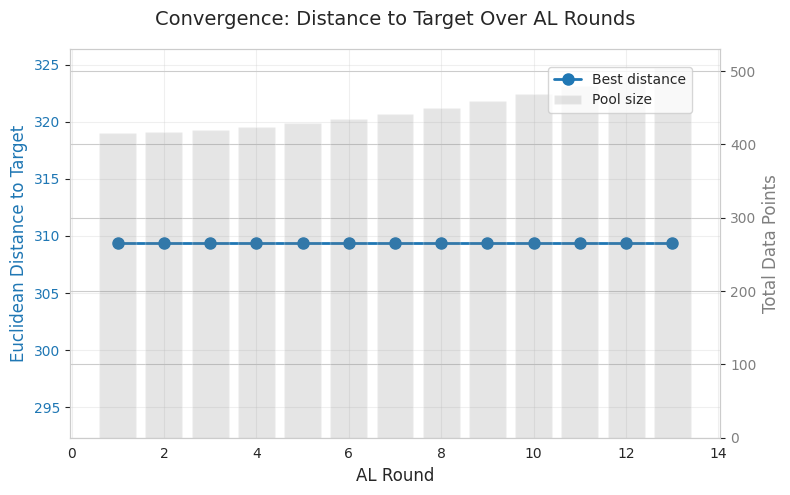

In [ ]:
# Figure: Convergence — distance to target over rounds
if len(al_history) == 0:
    print("No AL rounds recorded yet.")
else:
    rounds    = [h['round'] for h in al_history]
    best_d    = [h['best_distance'] for h in al_history]
    pool_size = [h['n_pool'] for h in al_history]

    fig, ax1 = plt.subplots(figsize=(8, 5))
    color1 = 'tab:blue'
    ax1.plot(rounds, best_d, 'o-', color=color1, lw=2, ms=8, label='Best distance')
    ax1.set_xlabel('AL Round', fontsize=12)
    ax1.set_ylabel('Euclidean Distance to Target', color=color1, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    color2 = 'tab:gray'
    ax2.bar(rounds, pool_size, alpha=0.2, color=color2, label='Pool size')
    ax2.set_ylabel('Total Data Points', color=color2, fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color2)

    fig.suptitle('Convergence: Distance to Target Over AL Rounds', fontsize=14)
    fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
    plt.tight_layout()
    plt.savefig('fig1_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()

The best distance barely decreases and stays nearly flat, indicating little meaningful convergence.Even as the pool size grows, the algorithm does not discover samples closer to the target. This suggests the active learning policy is not improving target matching, possibly due to local trapping or surrogate bias.

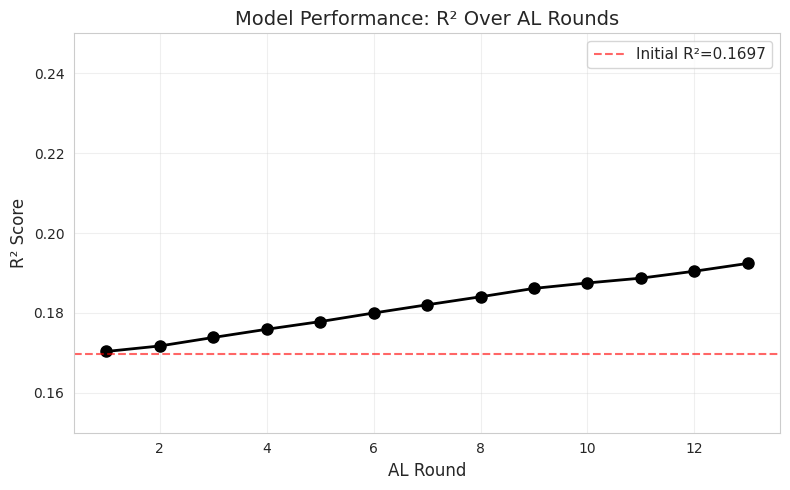

In [ ]:
# Figure: Predictive accuracy — R² over rounds
if len(al_history) > 0:
    r2_vals = [h['r2'] for h in al_history]

    plt.figure(figsize=(8, 5))
    plt.plot(rounds, r2_vals, 'ko-', lw=2, ms=8)
    plt.axhline(y=init_r2, color='r', ls='--', alpha=0.6, label=f'Initial R²={init_r2:.4f}')
    plt.xlabel('AL Round', fontsize=12)
    plt.ylabel('R² Score', fontsize=12)
    plt.title('Model Performance: R² Over AL Rounds', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(0.15, 0.25)
    plt.tight_layout()
    plt.savefig('fig2a_r2.png', dpi=150, bbox_inches='tight')
    plt.show()

The R² shows a steady increase from 0.17 to 0.19 over 13 rounds, but the improvement is small and the absolute level remains low. This indicates limited explanatory power and likely weak generalization.

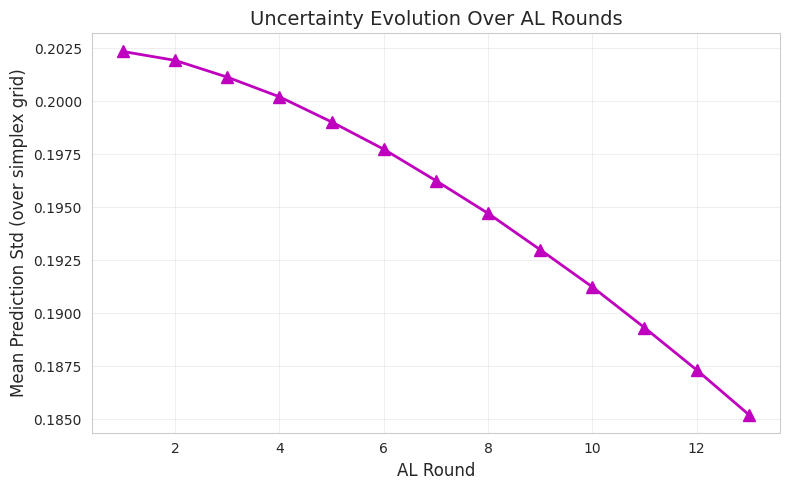

In [ ]:
# Figure: Uncertainty evolution over rounds
if len(al_history) > 0:
    unc_vals = [h['mean_uncertainty'] for h in al_history]

    plt.figure(figsize=(8, 5))
    plt.plot(rounds, unc_vals, 'm^-', lw=2, ms=8)
    plt.xlabel('AL Round', fontsize=12)
    plt.ylabel('Mean Prediction Std (over simplex grid)', fontsize=12)
    plt.title('Uncertainty Evolution Over AL Rounds', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig2b_uncertainty.png', dpi=150, bbox_inches='tight')
    plt.show()

The mean prediction standard deviation decreases monotonically from 0.20 to 0.18, representing an approximately 8.5% reduction over 13 rounds. This smooth, consistent decline confirms that the new data points are reducing global model uncertainty. However, the rate of decrease is roughly linear rather than showing any acceleration, suggesting the AL-selected points are not preferentially reducing uncertainty in the most critical regions (near the target).

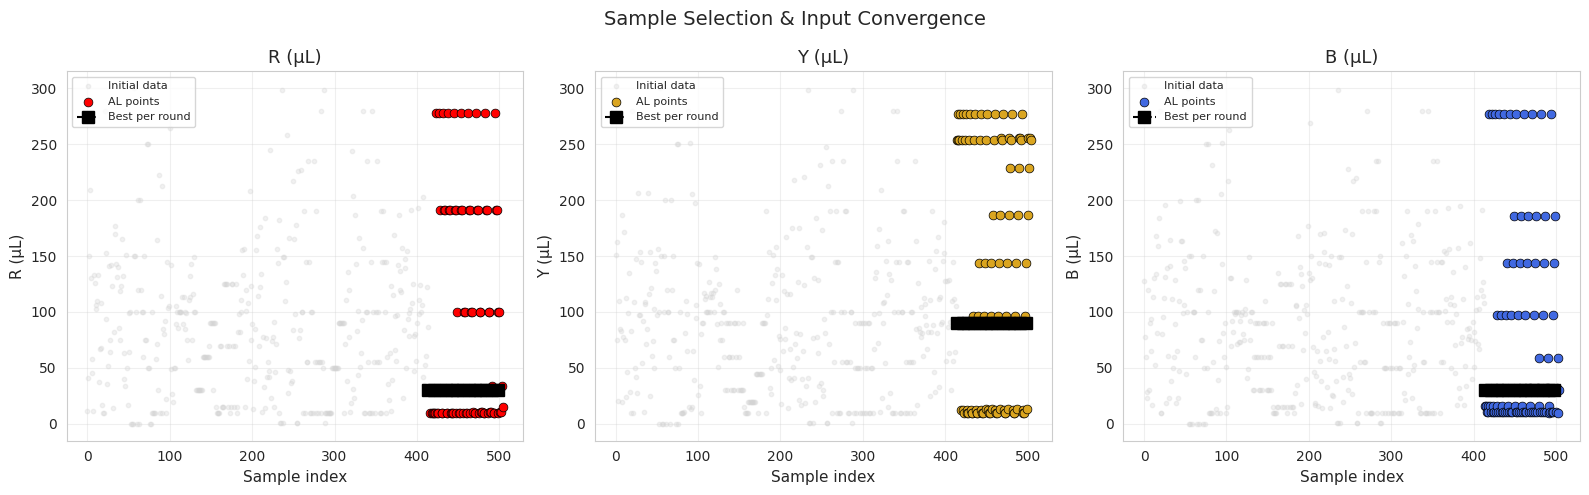

In [ ]:
# Figure: Sample selection and convergence to target input
if len(al_history) > 0:
    # Collect all newly-added points (after initial pool)
    n_init = len(X_init)
    new_pts = X_pool[n_init:]   # all AL-selected points
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    # Best RYB trajectory per round
    best_rgbs = np.array([h['best_rgb'] for h in al_history])

    labels = ['R (µL)', 'Y (µL)', 'B (µL)']
    colors_rgb = ['red', 'goldenrod', 'royalblue']
    for j in range(3):
        ax = axes[j]
        # Initial pool scatter (gray)
        ax.scatter(range(n_init), X_init[:, j], c='lightgray', s=10, alpha=0.3, label='Initial data')
        # New AL points (colored by round)
        if len(new_pts) > 0:
            ax.scatter(range(n_init, n_init+len(new_pts)), new_pts[:, j],
                       c=colors_rgb[j], s=40, edgecolors='k', lw=0.5, label='AL points', zorder=5)
        # Best trajectory
        ax.plot([n_init + i * (len(new_pts)//max(len(rounds),1)) for i in range(len(rounds))],
                best_rgbs[:, j], 's--', color='black', ms=8, label='Best per round', zorder=6)
        ax.set_xlabel('Sample index', fontsize=11)
        ax.set_ylabel(labels[j], fontsize=11)
        ax.set_title(labels[j], fontsize=13)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Sample Selection & Input Convergence', fontsize=14)
    plt.tight_layout()
    plt.savefig('fig3_sample_selection.png', dpi=150, bbox_inches='tight')
    plt.show()

Newly selected samples increasingly cluster into a limited set of compositions, shrinking exploration. The black squares marking best per round remain fixed.

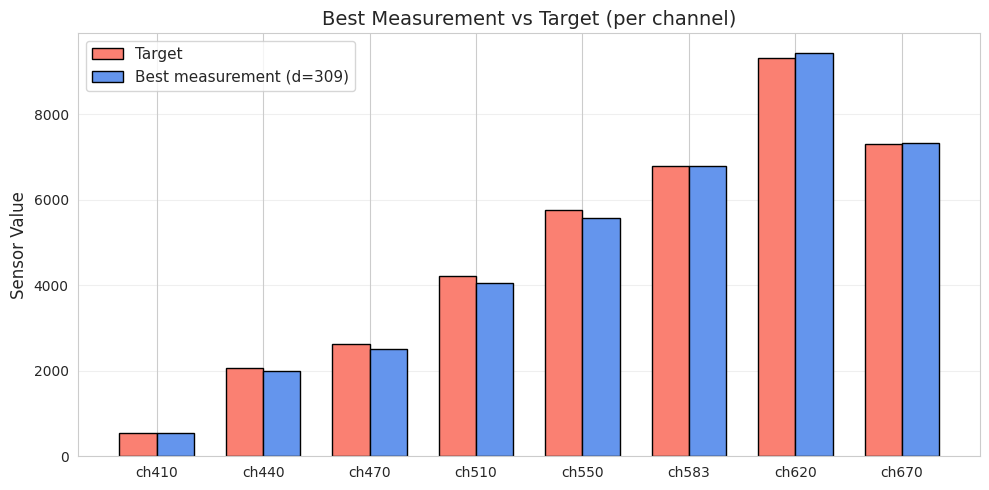

In [ ]:
# Figure: Per-channel comparison — best measurement vs target
if len(al_history) > 0:
    best_sensors = al_history[-1]['best_sensors']
    best_dist    = al_history[-1]['best_distance']

    x_pos = np.arange(8)
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x_pos - width/2, target_raw, width, label='Target', color='salmon', edgecolor='k')
    ax.bar(x_pos + width/2, best_sensors, width, label=f'Best measurement (d={best_dist:.0f})',
           color='cornflowerblue', edgecolor='k')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(SENSOR_COLS, fontsize=10)
    ax.set_ylabel('Sensor Value', fontsize=12)
    ax.set_title('Best Measurement vs Target (per channel)', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig4_channel_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

The best measurement is close to the target for many channels, but systematic deviations remain. Some channels overshoot while others undershoot, so the overall distance stays relatively large.

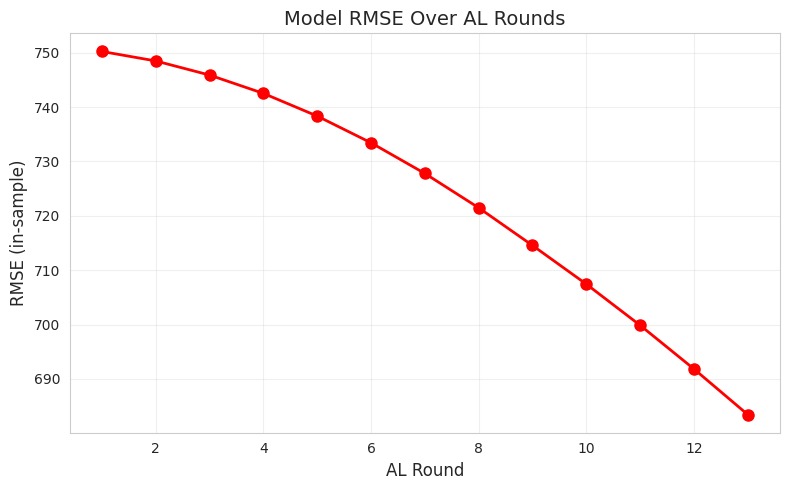

In [ ]:
# Figure: Model RMSE evolution
if len(al_history) > 0:
    rmse_vals = [h['rmse'] for h in al_history]

    plt.figure(figsize=(8, 5))
    plt.plot(rounds, rmse_vals, 'ro-', lw=2, ms=8)
    plt.xlabel('AL Round', fontsize=12)
    plt.ylabel('RMSE (in-sample)', fontsize=12)
    plt.title('Model RMSE Over AL Rounds', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig5_rmse.png', dpi=150, bbox_inches='tight')
    plt.show()

The RMSE decreases steadily from ~750 to ~683 over 13 AL rounds, representing an approximate 9% reduction. This downward trend mirrors the R² improvement and uncertainty reduction, confirming that the additional data consistently improves model fit. Given the low R², the improvement appears incremental rather than a structural leap in predictive quality.

# **3. Summary**

The True vs Predicted plots reveal that both training and test predictions fall into a narrow range, with low true values overestimated and high true values underestimated, suggesting underfitting or insufficient input information to explain output variability. With an R² of ~0.17, the GPR model explained less than 20% of the variance in sensor responses. Its predictions were nearly flat across the entire RYB simplex, making it unable to distinguish promising regions from poor ones. For active learning, over 13 rounds, R² rose from 0.170 to 0.192, RMSE fell from 750 to 683, and mean prediction uncertainty dropped by 8.5%. These improvements confirm that new data is informative for the model. However, the improvement rate was approximately linear.



**Does active learning make data more informative?** In this experiment, active learning made the surrogate more certain but not clearly more informative for the target goal. RMSE and predictive uncertainty decreased over rounds, showing improved fit and confidence. However, R² increased only slightly (~0.17 to ~0.19), and the key objective, distance to the target vector, barely improved. Point 2 remained the closest, and neither the 7 high-uncertainty samples nor the 4 local refinement samples produced a better match. Overall, you mostly collected more data and increased model confidence, rather than gaining information that moves you closer to the target.